# Fine-Tuning ProPicker

In this notebook, we discuss fine-tuning ProPicker for picking ribosomes in the EMPIAR-10988 dataset. 

We follow the setup from Section 4.3.2 of our paper and use a center crop of size `128x128x128` extracted from the `TS_029` tomogram and corresponding ground truth-annotations for fine-tuning. The crop contains 65 ribosomes which is less than 3% of the total number of ribosomes in the full `TS_029` tomogram.
For early stopping, and calibration of cluster-based picking we use `128x128x128` a center crop from `TS_030` and corresponding ground-truth annotations (66 ribosomes).


In [1]:

from matplotlib import pyplot as plt
import numpy as np
import torch

from propicker.clustering_and_picking import get_cluster_centroids_df
from propicker.evaluation import get_best_case_cluster_based_picking_performance, evaluate_picks
from propicker.data.preparation_functions.prepare_empiar10988 import read_empiar10988_coords, empiar10988_ts_to_slice_of_interest
from propicker.inference.tomotwin import get_tomotwin_prompt_embeds_dict
from propicker.paths import TOMOTWIN_MODEL_FILE
from propicker.utils.mrctools import load_mrc_data

# sometimes, jupyer notebooks have trouble reading the environment variables, so you can also set the paths here directly
TOMOTWIN_MODEL_FILE = "/workspaces/ProPicker/tomotwin.pth" if TOMOTWIN_MODEL_FILE is None else TOMOTWIN_MODEL_FILE

## Step 0: Setup Conda Environment for Fine-Tuning

Fine-tuning ProPicker works with our `DeepETPicker_ProPicker` fork of the [DeepETPicker](https://github.com/cbmi-group/DeepETPicker), which is integrated as a submodule. 

To run the fine-tuning code as described below, you need another conda environment (`deepetpicker`). You can create it by running
```bash
conda env create -f ../../propicker/DeepETPicker_ProPicker/environment.yml
conda activate deepetpicker
pip install ../../propicker
```
from the root of the ProPicker repository. The last step installs ProPicker in the `deepetpicker` conda environment.

Finally, we have to set the paths to the ProPicker and TomoTwin models as environment variables, just like before:
```bash
export POPICKER_MODEL_FILE=abs/path/to/propicker.ckpt
export PROPICKER_MODEL_FILE=abs/path/to/tomotwin.pth
```

## Step 1: Prompt extraction and embedding

For fine-tuning ProPicker, we first need to extract a prompt, which is used to condition the model and which we keep fixed during fine-tuning. We use the same prompt from `TS_030` as in `tutorial1`.

In [2]:
# this code is the same as in tutorial1
EMPIAR10988_BASE_DIR = "../empiar/10988/DEF"
ts_id = "TS_030"

tomo_file = f"{EMPIAR10988_BASE_DIR}/tomograms/{ts_id}.rec"
ribo_coord_file = f"{EMPIAR10988_BASE_DIR}/particle_lists/{ts_id}_cyto_ribosomes.csv"

slice_of_interest = empiar10988_ts_to_slice_of_interest[ts_id]
tomo = -1 * load_mrc_data(tomo_file).float()
tomo = tomo[slice_of_interest].clone()


coords = read_empiar10988_coords(ribo_coord_file)
coords.Z -= slice_of_interest.start

all_ribo_subtomos = []
for coord in coords[["X", "Y", "Z"]].values.astype(int):
    x, y, z = coord
    subtomo = tomo[
        z-18:z+19,
        y-18:y+19,
        x-18:x+19
    ]
    if not subtomo.shape == (37, 37, 37):
        continue
    all_ribo_subtomos.append(subtomo)
    
prompt = all_ribo_subtomos[300]
prompt_subtomos_dict = {"cyto_ribosome": prompt}

/opt/conda/envs/ppicker/lib/python3.11/site-packages/propicker/utils/mrctools.py:8: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /opt/conda/conda-bld/pytorch_1720538437738/work/torch/csrc/utils/tensor_numpy.cpp:206.)
  data = torch.from_numpy(mrc.data)


We embed the prompt using tomotwin and save the embedding to disk, as we need it for fine-tuning.

In [3]:
prompt_embeds_dict = get_tomotwin_prompt_embeds_dict(
    prompt_subtomos_dict=prompt_subtomos_dict, 
    tomotwin_model_file=TOMOTWIN_MODEL_FILE, 
    device="cuda:0", 
    batch_size=1, 
    out_file="./fixed_prompts_empiar10988.json"
)

/opt/conda/envs/ppicker/lib/python3.11/site-packages/propicker/inference/tomotwin.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weightspth, ma

## Step 2: Fine-tuning

Code for fine-tuning is in `empiar10988_fine_tuning.py`. We recommend to have a look at the code as there are some hyperparameters that can be adjusted, then run the script in the `deepetpicker` environment:

```bash
conda activate deepetpicker
python empiar10988_fine_tuning.py
```

With the current settings, the script fine-tunes ProPicker on a crop of size `128x128x128` voxels extracted from the center of `TS_029`. A center crop of the same size taken from `TS_030` is used as validation set.

Running the fine-tuning script will create a directory `fine_tuning_empiar10988/crop_delta=64`, which contains all outputs produced in hte process. You can monitor the fine-uning using TensorBoard.

## Step 3: Inference with the fine-tuned model

Inference with the fine-tuned model is handled in `empiar10988_inference.py`, which must also be run in the `deepetpicker` environment:
```bash
python empiar10988_inference.py
```

**Important:** Before you can run the script, you have to adjust the path to the model checkpoint in the script itself.

Within `fine_tuning_empiar10988/crop_delta=64/runs`, you can now find the `full_segmentation_output` directory which contains the full 3D segmentation mask of the test tomogram produced with the fine-tuned model. Let's have a look at it:

/tmp/ipykernel_199124/3097230430.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pred_locmap = torch.load("./fine_tuning_empiar10988/crop_delta=64/runs/train/train_ProPi

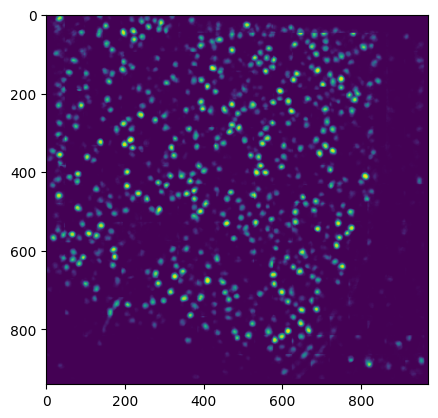

In [4]:
pred_locmap = torch.load("./fine_tuning_empiar10988/crop_delta=64/runs/train/train_ProPicker_BlockSize72_CELoss_MaxEpoch75_bs8_lr0.001_IP1_bg1_coord1_Softmax0_bn__TNNone/version_0/full_segmentation_output/TS_030.pt")
plt.imshow(pred_locmap[100])

## Step 4: Calibrating the fine-tuned model

Like for prompt-based picking, the fine-tuned model also requires calibration. After fine-tuning, calibration is usually easier since the model output has higher confidence and more clearly separated clusters.

As in the first tutorial, we use a grid search on the calibration tomogram `TS_030` to find the best hyperparameters for clustering-based picking.


In [5]:
# see TUTORIAL1 for explanation of this
bbox_size = 27
coords["height"] = coords["width"] = coords["depth"] = bbox_size

calibrated_results = get_best_case_cluster_based_picking_performance(
    pred_locmap_dict={"cyto_ribosome": pred_locmap},
    optimize_thresh=True, 
    n_thresh_steps=10,  
    n_size_steps=5,  
    gt_positions=coords,
    metric="F1",  
    num_workers=0,
    iou_thresh=0.6
)["cyto_ribosome"]
print(f"F1: {calibrated_results['F1']:.2f}, Precision: {calibrated_results['Precision']:.2f}, Recall: {calibrated_results['Recall']:.2f}") 


Running evaluation with 1 workers
Optimizing threshold for cyto_ribosome between 0.0 and 0.9742446541786194


cyto_ribosome (Best F1: 0.67): 100%|██████████| 250/250 [05:34<00:00,  1.34s/it]

F1: 0.67, Precision: 0.70, Recall: 0.63


## Step 5: Evaluation of the fine-tuned model with calibrated parameters

Finally, we evaluate the picking performance of the fine-tuned and calibrated ProPicker on the 8 test tomograms of `EMPIAR-10988`.

In [6]:
calibrated_binarization_thresh = calibrated_results['thresh']
calibrated_min_size = calibrated_results['min_size']
calibrated_max_size = calibrated_results['max_size']

In [7]:
# we used these 8 tomograms for evaluation in the paper
all_ts_ids = ["TS_026", "TS_027", "TS_028", "TS_034", "TS_037", "TS_041", "TS_043", "TS_045"]

all_f1s, all_precisions, all_recalls = [], [], []
for ts_id in all_ts_ids:
    # load tomo and annotations
    ribo_coord_file = f"{EMPIAR10988_BASE_DIR}/particle_lists/{ts_id}_cyto_ribosomes.csv"
    slice_of_interest = empiar10988_ts_to_slice_of_interest[ts_id]
    coords = read_empiar10988_coords(ribo_coord_file)
    coords.Z -= slice_of_interest.start
    # load predicted locmap using the fine-tuned model
    locmap_file = f"./fine_tuning_empiar10988/crop_delta=64/runs/train/train_ProPicker_BlockSize72_CELoss_MaxEpoch75_bs8_lr0.001_IP1_bg1_coord1_Softmax0_bn__TNNone/version_0/full_segmentation_output/{ts_id}.pt"
    pred_locmap = torch.load(locmap_file)
    # getting picks via clustering and filtering using calibrated hyperparameters
    binary_locmap = pred_locmap > calibrated_binarization_thresh
    cluster_centroids = get_cluster_centroids_df(binary_locmap)
    cluster_centroids_filt = cluster_centroids[
        (calibrated_min_size <= cluster_centroids["size"]) & (cluster_centroids["size"] <= calibrated_max_size)
    ].copy()
    # evaluate picks
    cluster_centroids_filt["height"] = cluster_centroids_filt["width"] = cluster_centroids_filt["depth"] = bbox_size
    coords["height"] = coords["width"] = coords["depth"] = bbox_size
    cluster_centroids_filt["class"] = "cyto_ribosome"
    results = evaluate_picks(
        pred_positions=cluster_centroids_filt,
        gt_positions=coords,
        iou_thresh=0.6,
    )["cyto_ribosome"]
    print(f"F1: {results['F1']:.2f}, Precision: {results['Precision']:.2f}, Recall: {results['Recall']:.2f}")
    all_f1s.append(results["F1"])
    all_precisions.append(results["Precision"])
    all_recalls.append(results["Recall"])


/tmp/ipykernel_199124/3873847893.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pred_locmap = torch.load(locmap_file)


F1: 0.57, Precision: 0.56, Recall: 0.59


/tmp/ipykernel_199124/3873847893.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pred_locmap = torch.load(locmap_file)


F1: 0.64, Precision: 0.65, Recall: 0.63


/tmp/ipykernel_199124/3873847893.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pred_locmap = torch.load(locmap_file)


...

F1: 0.52, Precision: 0.62, Recall: 0.44


/tmp/ipykernel_199124/3873847893.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pred_locmap = torch.load(locmap_file)


F1: 0.52, Precision: 0.50, Recall: 0.53


/tmp/ipykernel_199124/3873847893.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pred_locmap = torch.load(locmap_file)


F1: 0.45, Precision: 0.54, Recall: 0.39


The mean performance metrics below should be close to the ones reported in Figure 6 and Figure H.2 for fine-tuning on the $128\times128\times128$ crop.

In [8]:
print(f"Mean F1: {np.mean(all_f1s):.2f} ± {np.std(all_f1s):.2f}")
print(f"Mean Precision: {np.mean(all_precisions):.2f} ± {np.std(all_precisions):.2f}")
print(f"Mean Recall: {np.mean(all_recalls):.2f} ± {np.std(all_recalls):.2f}")

Mean F1: 0.54 ± 0.07
Mean Precision: 0.59 ± 0.07
Mean Recall: 0.51 ± 0.09


## Conclusion

Fine-tuning ProPicker on a small sub-tomogram significantly improves the performance of the model on the EMPIAR-10988 dataset. The fine-tuned model has higher precison and recall but most improvements are in recall.